<a href="https://colab.research.google.com/github/emxtorres/emxtorres/blob/main/Emerson_Torres_EP4_M%C3%A9todo_dos_m%C3%ADnimos_quadrados_MAP5729_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# MAP5729 - EP4: Método dos mínimos quadrados

---



Neste EP, iremos implementar o método dos mínimos quadrados, em suas versões discreta e contínua.

**Orientações:**
- Salve uma cópia deste notebook para editá-lo.
- As respostas das questões deverão ser respondidas nos espaços indicados abaixo.
- Envie o link do seu notebook na página de entrega da atividade no Moodle da disciplina.
- Data limite de entrega:

## Parte 1 - Método dos mínimos quadrados discreto

Vamos primeiramente resolver o problema de **ajuste de dados**: dados $m$ pontos $(x_i, y_i)$, $i = 1,\dots,m$, queremos encontrar a função

\begin{equation}
  g(x) = \sum_{i=0}^{n} a_i g_i(x)
\end{equation}

que melhor aproxime os pontos dados, no sentido de minimizar o erro quadrático

\begin{equation}
  E(a_0, \dots, a_n) := \sqrt{\sum_{i=1}^m \left(y_i - g(x_i)\right)^2}
\end{equation}

Em geral, $m > n+1$ e não existe uma função $g$ na forma acima tal que $E(a_0, \dots, a_n) = 0$.

Esse problema também pode ser formulado como um sistema linear sobredeterminado $A \mathbf{x} = \mathbf{b}$, com $A \in \mathbb{R}^{m \times(n+1)}$, $\mathbf{x} = (a_0, \dots, a_n)^T$, $\mathbf{b} = (y_1, \dots, y_m)^T$ e as colunas de $A$ sendo dadas pelos vetores $\mathbf{a}_j = (g_j(x_1), \dots, g_j(x_m))^T$, $j = 0, \dots, n$. Esse sistema em geral não possui solução, então buscamos $\mathbf{x}^*$ que minimize o resíduo $||\mathbf{b} - A \mathbf{x}||_2$.

Em ambas as formulações, o método dos mínimos quadrados conduz à resolução do **sistema normal** $A^TA \mathbf{x} = A^T\mathbf{b}$, de tamanho $n+1$. As componentes de $A^TA$ e $A^T\mathbf{b}$ são dadas respectivamente por

\begin{equation}
  (A^TA)_{ij} = \langle \mathbf{q}_i, \mathbf{q}_j \rangle, \qquad (A^T \mathbf{b})_i = \langle \mathbf{q}_i, \mathbf{b} \rangle
\end{equation}

onde $\langle \cdot,\cdot \rangle$ é o produto interno usual em $\mathbb{R}^m$. O sistema normal possui uma única solução se as colunas de $A$ forem linearmente independentes.



### Questão 1.1.

Vamos inicialmente construir funções para constuir o sistema normal. A função *construir_matriz_A* recebe um vetor com pontos $x_i$ e uma lista $[g_0,\dots,g_n]$ com as funções da base, e retorna a matriz $A$ do sistema sobredeterminado. A função *construir sistema normal* recebe a matriz $A$ e uma vator de valores $y_i$ calculados nos pontos $x_i$, e retorna a matriz $A^T A$ e o vetor $A^T \mathbf{b}$.

Produtos escalares entre vetores e produtos matriz-vetor podem ser efetuados usando a função *np.dot*.

In [2]:
"""
Constroi a matriz A do sistema linear sobredeterminado

Entradas:
- xs: vetor com os pontos x_i (tamanho m)
- gs: lista de funções g_j (tamanho n + 1)

Saídas:
- A: matriz de tamanho m x (n+1)
"""

def construir_matriz_A(xs, gs):
  m = len(xs)
  n = len(gs) - 1
  A = np.zeros((m,n+1), dtype=float)

  for i in range(m):
    for j in range(n+1):
      A[i,j] = gs[j](x[i])
  return A

"""
Constroi o sistema normal A^TAx = A^Tb

Entradas:
- A: matriz de tamanho m x (n+1)
- ys: vetor com os pontos y_i (tamanho m)

Saídas:
- ATA: matriz do sistema normal (tamanho m)
- ATb: vetor do lado direito do sistema normal (tamanho m)
"""

def construir_sistema_normal(A,ys):
  ATA = np.matmul(A.T,A)
  ATb = np.matmul(A.T,ys)
  return ATA, ATb

O sistema normal $A^TA \mathbf{x} = A^T \mathbf{b}$ será resolvido usando a fatoração de $QR$ de $A$. Se $A \in \mathbb{R}^{m \times (n+1)}$, com $m \geq n+1$, existem $Q \in \mathbb{R}^{m \times (n+1)}$ e $R \in \mathbb{R}^{(n+1) \times (n+1)}$, com $R$ triangular superior e $Q$ satisfazendo $Q^T Q = I_n$.

Substituindo $A = QR$ em $A^T A \mathbf{x} = A^T \mathbf{b}$, temos

\begin{equation}
  R^T Q^T Q R \mathbf{x} = R^T Q^T \mathbf{b} \iff R^T R \mathbf{x} = R^T Q^T \mathbf{b} \iff R \mathbf{x} = Q^T \mathbf{b}
\end{equation}

onde usamos o fato de que $R$ é não-singular se as colunas de $A$ são linearmente independentes. Portanto, usando a fatoração $QR$, a solução do sistema normal é dada pela solução de um sistema triangular superior.

As matrizes $Q$ e $R$ podem ser determinados aplicando o processo de **ortonormalização de Gram-Schmidt**; porém, este algoritmo é sensível a erros de arredondamento se as colunas de $A$ forem quase linearmente dependentes. Portanto, iremos calcular $Q$ e $R$ usando matrizes de Householder.

<!-- As matrizes $Q$ e $R$ podem ser determinados aplicando o processo de **ortonormalização de Gram-Schmidt** às colunas $\mathbf{a}_j$, $j = 1, \dots, n+1$, de $A$. Sejam $\mathbf{q}_j$, $j = 1, \dots, n+1$, as colunas de $Q$ e $r_{ij}$, $1 \leq i,j, \leq n+1$, os elementos de $r$, com $r_{ij} = 0$ se $i > j$. Começamos definindo

\begin{equation}
  r_{11} = ||\mathbf{a}_1||_2, \qquad \mathbf{q}_1 = \frac{1}{r_{11}} \mathbf{a}_1
\end{equation}

\noindent e em seguida, para cada coluna $j = 2, \dots, n+1$,

\begin{equation}
  \begin{aligned}
    r_{ij} & = \langle \mathbf{q}_i, \mathbf{a}_j \rangle,\qquad i = 1, \dots, j-1\\
    \mathbf{b}_j &= \mathbf{a}_j - \sum_{i = 1}^{j-1} \text{proj}_{\mathbf{q}_i} \mathbf{a}_j = \mathbf{a}_j - \sum_{i = 1}^{j-1} \frac{\langle \mathbf{q}_i, \mathbf{a}_j\rangle}{\langle\mathbf{q}_i,\mathbf{q}_i\rangle} \mathbf{q}_i  = \mathbf{a}_j - \sum_{i = 1}^{j-1} r_{ij} \mathbf{q}_i\\
    r_{jj} & = ||\mathbf{b}_j||_2\\
    \mathbf{q}_j &= \frac{1}{r_{jj}} \mathbf{b}_j
  \end{aligned}
\end{equation} -->

**Fatoração QR usando matrizes de Householder**

Seja $A \in \mathbb{R}^{M \times N}$. Para simplificar a apresentação do algoritmo, vamos considerar uma implementação menos econômica, e vamos definir uma matriz quadrada $\hat{A} \in \mathbb{R}^{M \times M}$, obtida adicionando-se $M-N$ colunas nulas em $A$. Seja $A^{(0)} := \hat{A}$

Para $j = 1, \dots, M-1$, definimos $A^{(j)} := H^{(j-1)} A^{(j-1)}$, onde $H^{(j-1)}  \in \mathbb{R}^{M \times M}$ é uma matriz de Householder tal que se produzam zeros abaixo da diagonal da coluna $j$ de $A^{(j)}$. Logo,

\begin{equation}
  A^{(M-1)} = H^{(M-2)}A^{(M-2)} = H^{(M+1)}\dots H^{(0)}\hat{A} =: \hat{R} \in \mathbb{R}^{M \times M}
\end{equation}

é uma matriz triangular superior. Usando o fato de que matrizes de Householder são ortogonais, sendo portanto não-singulares e com inversa igual à sua transposta, e que o produto de matrizes ortogonais também é ortogonal, obtemos a fatoração $A = QR$, onde

\begin{equation}
  \hat{Q} := \left(H^{(0)}\right)^T \dots \left(H^{(M-2)}\right)^T = H^{(0)} \dots H^{(M-2)} \in \mathbb{R}^{M \times M}
\end{equation}

Observe que as matrizes $\hat{Q}$ e $\hat{R}$ são maiores que o necessário, já que partimos de uma matriz $\hat{A}$ quadrada contendo colunas nulas. Para obter $Q  \in \mathbb{R}^{M \times N}$, basta extrair as $N$ primeiras colunas de $\hat{Q}$. A matriz $R  \in \mathbb{R}^{N \times N}$ é a $N$-ésima submatriz principal de $\hat{R}$. Observe também que, como as colunas $N+1, \dots, M$ de $\hat{A}$ são nulas, é suficiente executar o algoritmo apenas até o passo $N$, ou seja, podemos tomar

\begin{equation}
  \hat{R} := A^{(N)}, \qquad \hat{Q} := \left(H^{(0)}\right)^T \dots \left(H^{(N-1)}\right)^T = H^{(0)} \dots H^{(N-1)}
\end{equation}

Resta definir como as matrizes $H^{(j)}$ são construídas. Primeiramente, recorde que, para qualquer matriz de Householder $H \in \mathbb{R}^{M \times M}$, existe $\mathbf{v} \in \mathbb{R}^M$ tal que

\begin{equation}
  H = H(\mathbf{v}) = I - \frac{2}{\mathbf{v}^T\mathbf{v}}\mathbf{v}\mathbf{v}^T
\end{equation}

A primeira matriz deve ser tal que $H^{(0)} \mathbf{a}_1^{(0)}$ é um múltiplo de $\mathbf{e}_1 \in \mathbb{R}^M$, onde $\mathbf{a}_1^{(0)} = \mathbf{a}_1$ é a primeira coluna de $A^{(0)}$. Então, definimos $H^{(0)} : = H^{(0)}(\mathbf{v}_0)$, onde

\begin{equation}
  \mathbf{v}_0  := \mathbf{\mathbf{a}}_1^{(0)} + c \mathbf{e}_1 \in \mathbf{R}^M, \qquad
  c :=
  \begin{cases}
  \frac{|a_{11}^{(0)}|}{a_{11}^{(0)}} ||\mathbf{a}_1^{(0)}||_2,& a_{11}^{(0)} \neq 0\\
  ||\mathbf{a}_1^{(0)}||_2,& a_{11}^{(0)} = 0
  \end{cases}
\end{equation}

As demais matrizes são construídas de forma análoga, mas levando em consideração que elas devem anular apenas os elementos abaixo da diagonal na coluna $j$. Seja $\tilde{\mathbf{a}}_j^{(j-1)} := (a_{jj}^{(j-1)}, \dots, a_{Mj}^{(j-1)})^T \in \mathbb{R}^{M-j+1}$ o vetor contendo apenas os elementos abaixo da diagonal na coluna $j$ de $A^{(j-1)}$. Definimos então a matriz de Householder $\tilde{H}^{(j-1)}$ tal que $\tilde{H}^{(j-1)}\tilde{\mathbf{a}}_j^{(j-1)}$ seja um múltiplo de $\mathbf{e}_1 \in \mathbb{R}^{M-j+1}$. Essa matriz é dada por

\begin{equation}
  \tilde{H}^{(j-1)} := \tilde{H}^{(j-1)}(\mathbf{v}_{j-1}), \qquad \mathbf{v}_{j-1}  := \mathbf{\tilde{\mathbf{a}}}_j^{(j-1)} + c \mathbf{e}_1 \in \mathbf{R}^{M-j+1}, \qquad
  c :=
  \begin{cases}
  \frac{|a_{jj}^{(j-1)}|}{a_{jj}^{(j-1)}} ||\tilde{\mathbf{a}}_{j}^{(j-1)}||_2,& a_{jj}^{(j-1)} \neq 0\\
  ||\tilde{\mathbf{a}}_{j}^{(j-1)}||_2,& a_{jj}^{(j-1)} = 0
  \end{cases}
\end{equation}

Por fim, definimos

\begin{equation}
H^{(j-1)} :=
\left(
  \begin{array}{c c}
  I_{j-1} & 0\\
  0 & \tilde{H}^{(j-1)}
  \end{array}
\right) \in \mathbb{R}^{M \times M}
\end{equation}

que, conforme visto em aula, também é uma matriz de Householder.

### Questão 1.2.

Complete as funções abaixo permitindo calcular a fatoração QR usando matrizes de Householder e resolver o sistema normal usando a fatoração QR, conforme descrito acima:
- Função *completar_colunas*: transforma a matriz retangular em uma matriz quadrada, completando com colunas nulas à direita;
- Função *matriz_Householder*: calcula a matriz de Householder associada a um vetor $\mathbf{v}$;
- Função *vetor_Householder*: dado um vetor $\mathbf{x}$, determina o vetor $\mathbf{v}$ tal que $H(\mathbf{v})\mathbf{x}$ seja um múltiplo de $\mathbf{e}_1$;
- Função *QR_Householder*: calcula a fatoração QR de $A$ usando matrizes de Householder;
- Função *resolver_sistema_triangular_superior*: resolve um sistema triangular superior $R \mathbf{x} = \mathbf{z}$.


Algumas funções úteis:
- *np.eye(M)*: retorna a matriz identidade de tamanho $M$;
- *np.dot(u,v)*: retorna o produto interno $\mathbf{u}^T\mathbf{v}$ entre os vetores $\mathbf{u}$ e $\mathbf{v}$;
- *np.dot(A,u)*: retorna o produto matriz-vetor $A \mathbf{u}$;
- *np.dot(A,B)*: retorna o produto matricial $AB$;
- *np.outer(u,v)*: retorna o produto externo $\mathbf{u}\mathbf{v}^T$ entre os vetores $\mathbf{u}$ e $\mathbf{v}$;
- *A.T*, ou *np.transpose(A)*, ou *A.transpose()*: transposta da matriz $A$;
- *np.sign(x)*: retorna o sinal do escalar $x$.

In [3]:
"""
Dada uma matriz não quadrada de tamanho MxN, com M > N, produz uma matriz quadrada de tamanho M, adicionado colunas nulas a A (à direita)

Entrada:
- A: matriz de tamanho MxN, M > N

Saídas:
- A_hat: matriz quadrada de tamanho M
"""
def completar_colunas(A):
  M=len(A)
  N=len(A[0])
  A_hat=A.copy()
  zero = np.zeros(M,dtype=float)
  for i in range(M-N):
    A_hat=np.column_stack((A_hat,(zero.T)))
  return A_hat




"""
Constroi a matriz de Householder H = H(v)

Entrada:
- v: vetor de tamanho M

Saídas:
- H: matriz de Householder de tamanho M x M
"""
def matriz_Householder(v):
  ## COMPLETAR
  M=len(v)
  if np.linalg.norm(v) < 1e-14:
    return np.eye(M)
  H=np.eye(M)-(2)*(np.outer(v, v )/np.dot(v,v))
  return H



"""
Constroi o vetor v tal que H(v)x é um múltiplo de e_1

Entrada:
- x: vetor de tamanho M

Saídas:
- v: vetor de tamanho M
"""
def vetor_Householder(x):
  n=len(x)
  e1 = np.zeros(n)
  e1[0] = 1
  c=0
  r=0
  if x[0]!=0:
    c=np.sign(x[0])*np.linalg.norm(x)
  else:
    c=np.linalg.norm(x)
  v=x+c*e1
  #H0=matriz_Householder(r)

  #v=np.dot(H0,x)

  return v




"""
Constroi a fatoração QR de A usando matrizes de Householder

Entrada:
- A: matriz de tamanho M x N

Saídas:
- Q: matriz de tamanho M x N, satisfazendo Q^T Q = I_N
- R: matriz triangular superior de tamanho N x N
"""
def QR_Householder(A):
  N=len(A[0])
  Avar=completar_colunas(A)
  n=len(Avar)
  A0=Avar.copy()
  v=vetor_Householder(A0[0:,0])
  H0=matriz_Householder(v)
  A_j=np.matmul(H0,A0)
  Q=H0.copy()
  for j in range(1,N):
      v=vetor_Householder(A_j[j:,j])
      Hvar_j=matriz_Householder(v)
      H_j=np.eye(n)
      H_j[j:,j:]=Hvar_j
      Q=np.matmul(Q,H_j)
      A_j=np.matmul(H_j,A_j)
  R=A_j.copy()
  return -Q[:,:N],-R[:N,:N]





"""
Resolve o sistema triangular superior Rx = z

Entradas:
- R: matriz triangular de tamanho N x N
- z: vetor de tamanho N

Saídas:
- x: vetor de tamanho N
"""
def resolver_sistema_triangular_superior(A, b):
  n=len(b)
  x = np.zeros(n, dtype=float)
  cont=0
  epsilon = 1e-10
  for j in range(n):
    for i in range(j+1, n):
      if abs(A[i][j])>epsilon:
        cont+=1
  if(cont==0):
    for i in range(n-1, -1, -1):
      suma = float(0)
      for j in range(i+1, n):
        suma+=A[i][j]*x[j]
      x[i] = (b[i]-suma)/A[i][i]
  else:
    return "A matriz não é triangular superior"
  return x

def eliminacao_gauss(A, b, precision = None, pivotamento = False):
    n = len(A)
    A_copy = A.copy()
    b_copy = b.copy()
    for j in range(n):
        for i in range(j+1, n):
            m = ((-1)*(A_copy[i][j]))/(A_copy[j][j])
            b_copy[i] = b_copy[i] + m * b_copy[j]
            for k in range(j, n):
                A_copy[i][k] = A_copy[i][k] + m * A_copy[j][k]
    return resolver_sistema_triangular_superior(A_copy, b_copy)

### Questão 1.3.

Vamos inicialmente validar a função implementando o algoritmo de fatoração QR. Considere

\begin{equation}
  A = \left(\begin{array}{c c c}
  1 & 0\\
  1 & 1 \\
  0 & -1
  \end{array}\right)
\end{equation}

Verifique que sua função fornece

\begin{equation}
  Q = \left(\begin{array}{c c c}
  \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{6}}\\
  \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{6}}\\
  0 & -\frac{2}{\sqrt{6}}
  \end{array}\right), \qquad
  R = \left(\begin{array}{c c}
  \sqrt{2} & \frac{1}{\sqrt{2}} \\
  0 & \frac{3}{\sqrt{6}}
  \end{array} \right)
\end{equation}

Além disso, utilize a fatoração QR para resolver o sistema sobredeterminado

\begin{equation}
  \left(\begin{array}{c c c}
  1 & 0\\
  1 & 1 \\
  0 & -1
  \end{array}\right)
  \left(
    \begin{array}{c}
    x_1\\x_2
    \end{array}
  \right)
  =
  \left(
    \begin{array}{c}
    1\\1\\1
    \end{array}
  \right)
\end{equation}

e verifique que sua implementação fornece o mesmo resultado obtido resolvendo diretamente o sistema normal.

**Observação:** a fatoração QR não é única, então é possível que você obtenha alguns sinais trocados em $Q$ e $R$. No entanto, a solução do problema de MMQ é a mesma em todos os casos.

In [4]:
A = np.array([[1,0],[1,1],[0,-1]],dtype=float)      ## matriz A
b = np.array([1,1,1])

## Resultados de referência
Q_ref = np.array([[1/np.sqrt(2),-1/np.sqrt(6)],[1/np.sqrt(2),1/np.sqrt(6)],[0,-2/np.sqrt(6)]])
R_ref = np.array([[np.sqrt(2),1/np.sqrt(2)],[0,3/np.sqrt(6)]])
x_ref = eliminacao_gauss(np.matmul(A.T, A),np.matmul(A.T, b))

## Calcular fatoração QR de A
Q=QR_Householder(A)[0]
R=QR_Householder(A)[1]

## Resolver Ax = b por MMQ
x=resolver_sistema_triangular_superior(R, np.matmul(Q.T, b))


## Imprimir e comparar resultados
print("Q: \n{}".format(Q))
print("R: \n{}".format(R))
print("x: \n{}".format(x))
print("")
print("Q_ref: \n{}".format(Q_ref))
print("R_ref: \n{}".format(R_ref))
print("x_ref: \n{}".format(x_ref))
print("")
print("Q - Q_ref: \n{}".format(Q-Q_ref))
print("R - R_ref: \n{}".format(R-R_ref))
print("x - x_ref: \n{}".format(x-x_ref))

Q: 
[[ 0.70710678 -0.40824829]
 [ 0.70710678  0.40824829]
 [-0.         -0.81649658]]
R: 
[[ 1.41421356  0.70710678]
 [-0.          1.22474487]]
x: 
[ 1.33333333 -0.66666667]

Q_ref: 
[[ 0.70710678 -0.40824829]
 [ 0.70710678  0.40824829]
 [ 0.         -0.81649658]]
R_ref: 
[[1.41421356 0.70710678]
 [0.         1.22474487]]
x_ref: 
[ 1.33333333 -0.66666667]

Q - Q_ref: 
[[ 0.00000000e+00  1.11022302e-16]
 [ 0.00000000e+00 -1.11022302e-16]
 [-0.00000000e+00  1.11022302e-16]]
R - R_ref: 
[[-2.22044605e-16  0.00000000e+00]
 [-0.00000000e+00 -2.22044605e-16]]
x - x_ref: 
[ 2.22044605e-16 -1.11022302e-16]


### Questão 1.4.

Como primeiro exemplo, vamos resolver um problema de mínimos quadrados discreto linear nos parâmetros.

Um objeto pontual foi lançado verticalmente para cima, e sua altura $y$ for medida em $m$ instantes $t_1, \dots, t_m$, fornecendo os dados apresentados nos vetores do código abaixo. Da cinemática, sabemos que $y(t)$ é descrito por um polinômio quadrático.

- Use o MMQ para determinar o polinômio quadrático que melhor aproxima os dados do problema. Resolva usando a fatoração QR.
- Plote em um mesmo gráfico os pontos dados (*plt.scatter*) e o polinômio obtido (*plt.plot*).
- No modelo aproximado para a trajetória do corpo, quais são os valores estimados da altura inicial, da velocidade inicial e da aceleração da gravidade?

**Resposta**:

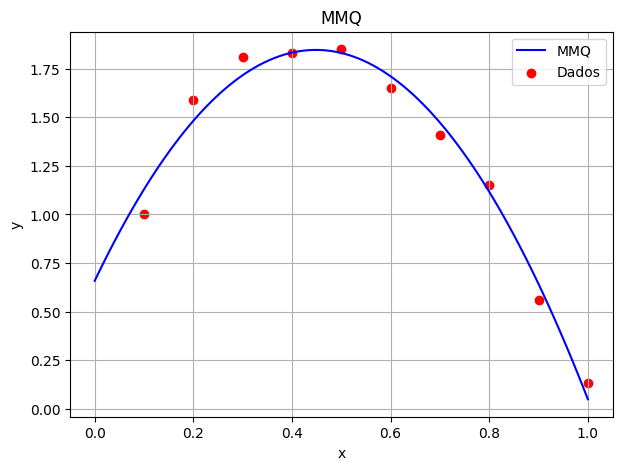

In [5]:
ts = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ys = np.array([1.00, 1.59, 1.81, 1.83, 1.85, 1.65, 1.41, 1.15, 0.56, 0.13])

## Definir as funções da base
def g0(t):
  ## COMPLETAR
  return 1.00

def g1(t):
  ## COMPLETAR
  return t

def g2(t):
  ## COMPLETAR
  return t**2

gs = [g0, g1, g2]

## Construir A e QR
A = np.array([[g(x) for g in gs] for x in ts])
Q,R = QR_Householder(A)

## Construir e resolver o sistema triangular superior
b=ys.copy()
x = resolver_sistema_triangular_superior(R, np.matmul(Q.T, b))


## Plotar
def pol(t):
    return x[0] + x[1]*t + x[2]*t**2

plt.figure(figsize=(7,5))
plt.plot(np.linspace(0,1,100), pol(np.linspace(0,1,100)), label='MMQ', color='blue')
plt.scatter(ts, ys, label='Dados', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MMQ')
plt.grid()
plt.legend()
plt.show()




### Questão 1.4.

Nesta questão e na próxima, vamos usar o MMQ discreto para resolver um problema de mínimos quadrados discreto não-linear nos parâmetros. Resolveremos um problema de crescimento populacional.

A raia olímpica da USP é habitada por capivaras desde 2013; desde então, a população de capivaras tem crescido; dados estimados de 2013 a 2018 são fornecidos no código abaixo (https://www.teses.usp.br/teses/disponiveis/10/10131/tde-31012020-130659/pt-br.php, cap. 5).

Vamos em um primeiro momento considerar um modelo de crescimento populacional exponencial, que supõe que a taxa de crescimento é proporcional ao número de indivíduos:

\begin{equation}
  P(t) = P_0 e^{r(t-t_0)}
\end{equation}

onde $P(t)$ é o número de indíviduos, $t$ é o tempo (anos), $t_0 = 2013$ é o tempo inicial, $P_0$ é a população inicial (não conhecida exatamente) e $r$ é a taxa de crescimento relativa da população (em $\text{ano}^{-1}$).

- Linearize o problema para que ele possa ser resolvido pelo método dos mínimos quadrados.
- Estime o valor de $P_0$ e $r$. Resolva usando a fatoração QR.
- Plote os dados fornecidos e a função construída, entre $t = 2013$ e $t = 2030$, com os parâmetros estimados.
- Estime o ano em que a população de capivaras da raia superará a quantidade de estudantes da USP (97 185, dados de 2023), supondo que esta última permaneça constante.

**Resposta:**

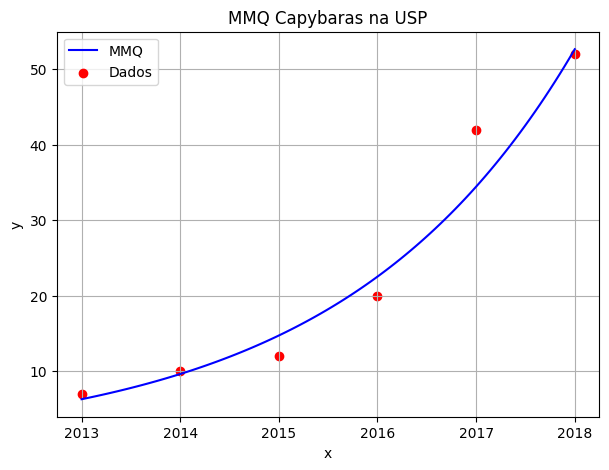

In [6]:
ts = np.array([2013,2014,2015,2016,2017,2018])
Ps = np.array([7,10,12,20,42,52])
ys = np.array([np.log(x) for x in Ps])

## Definir as funções da base
def g0(t):
  return 1.00

def g1(t):
  return t

gs = [g0, g1]

## Construir A e QR
A = np.array([[g(x) for g in gs] for x in ts])
Q,R = QR_Householder(A)

## Construir e resolver o sistema triangular superior
b=ys.copy()
x = resolver_sistema_triangular_superior(R, np.matmul(Q.T, b))

t0=2013
tf=2018
r=x[1]
P0=np.exp(x[0]+r*(t0))
## Plotar
def P(t):
    return P0*(np.exp(r*(t-t0)))


plt.figure(figsize=(7,5))
plt.plot(np.linspace(t0,tf,100), P(np.linspace(t0,tf,100)), label='MMQ', color='blue')
plt.scatter(ts, Ps, label='Dados', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MMQ Capybaras na USP')
plt.grid()
plt.legend()
plt.show()


### Questão 1.5

Obviamente, como visto acima, o modelo de crescimento populacional exponencial é de pouca utilidade a longo prazo. Um modelo mais adequado é o modelo de Gompertz (https://en.wikipedia.org/wiki/Gompertz_function), que leva em consideração uma população máxima $P_{max}$ suportada pelo ambiente e que a taxa de crescimento relativa é decrescente com o tempo:

\begin{equation}
  P(t) = P_{max} e^{-ae^{-b(t-t_0)}}
\end{equation}

onde $a$ é um parâmetro adimensional relacionado à população inicial e $b$ (em $\text{ano}^{-1}$) está relacionado à taxa de crescimento.

Supondo que a população máxima de capivaras na raia da USP seja $P_{max} = 100$:

- Linearize o problema para que ele possa ser resolvido pelo método dos mínimos quadrados
- Estime o valor de $a$ e $b$. Resolva usando a fatoração QR.
- Plote os dados fornecidos e a função construída, entre $t = 2013$ e $t = 2030$, com os parâmetros estimados.

**Resposta:**

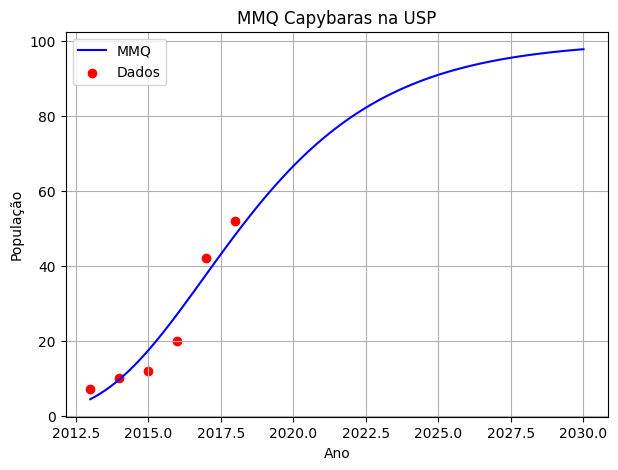

In [7]:
ts = np.array([2013,2014,2015,2016,2017,2018])
Ps = np.array([7,10,12,20,42,52])
Pmax=100
LPs= np.array([np.log(x/Pmax) for x in Ps])
ys = np.array([(np.log(-x)) for x in LPs])

## Definir as funções da base
def g0(t):
  return 1.00

def g1(t):
  return t

gs = [g0, g1]

## Construir A e QR
A = np.array([[g(x) for g in gs] for x in ts])
Q,R = QR_Householder(A)

## Construir e resolver o sistema triangular superior
b=ys.copy()
x = resolver_sistema_triangular_superior(R, np.matmul(Q.T, b))


t0=2013
tf=2030
b=-x[1]
a=np.exp(x[0]-b*(t0))
## Plotar
def P(t):
    return Pmax*(np.exp((-a)*np.exp((-b)*(t-t0))))

plt.figure(figsize=(7,5))
plt.plot(np.linspace(t0,tf,100), P(np.linspace(t0,tf,100)), label='MMQ', color='blue')
plt.scatter(ts, Ps, label='Dados', color='red')
plt.xlabel('Ano')
plt.ylabel('População')
plt.title('MMQ Capybaras na USP')
plt.grid()
plt.legend()
plt.show()

## COMPLETAR

### Questão 1.6.

Considere agora um sistema massa-mola amortecido, cujo movimento é descrito pela equação diferencial

\begin{equation}
  \tag{1}
  m x''(t) + c x'(t) + kx(t) = F(t)
\end{equation}

onde $m$ é a massa presa à mola, $k$ e $c$ são respectivamente as constantes de rigidez e amortecimento da mola, $x(t)$ é a posição da massa ao longo do tempo e $F$ é uma força externa aplicada. Considerando $F(t) = F_0 \sin(\omega t)$ e resolvendo (1) no domínio da frequência, obtemos

\begin{equation}
  y(\omega) := |X(\omega)|^2 = \frac{F_0^2}{k^2 - 2km\omega^2 + c^2 \omega^2 + m^2 \omega^4}
\end{equation}

onde $|X(\omega)|$ é a transformada de Fourier de $x$.

No código abaixo estão listados alguns valores medidos da frequência $\omega$ e os respectivos $y(\omega)$, obtidos aplicando-se uma força externa com $F_0 = 1$.

- Linearize o problema para que ele possa ser resolvido pelo método dos mínimos quadrados
- Estime o valor de $m$, $k$ e $c$. Resolva usando a fatoração QR.
- Plote os dados fornecidos e a função construída, entre $\omega = 0$ e $t = 10$, com os parâmetros estimados.

[17.10607502 -1.58342221  0.46138695]
4.135949107986387 0.6792547011162101 2.0088064976567908


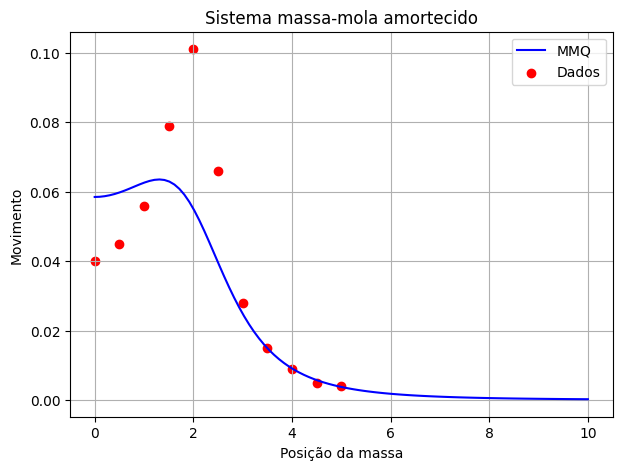

In [8]:
xs = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ys = np.array([0.040, 0.045, 0.056, 0.079, 0.101, 0.066, 0.028, 0.015, 0.009, 0.005, 0.004])
F0=1
ys2 = np.array([(1/x) for x in ys])

## Definir as funções da base
def g0(t):
  return 1.00

def g1(t):
  return t**2

def g2(t):
  return t**4

gs = [g0, g1, g2]


## Construir A e QR
A = np.array([[g(x) for g in gs] for x in xs])
Q,R = QR_Householder(A)

## Construir e resolver o sistema triangular superior
z=ys2.copy()
x = resolver_sistema_triangular_superior(R, np.matmul(Q.T, z))

print(x)

t0=0
tf=10
k=np.sqrt(x[0])
m=np.sqrt(x[2])
c=np.sqrt(x[1]+2*k*m)

print(k,m,c)
## Plotar
def P(t):
    return ((F0)/((k**2)-2*k*m*(t**2)+(c**2)*(t**2)+(m**2)*(t**4)))

plt.figure(figsize=(7,5))
plt.plot(np.linspace(t0,tf,100), P(np.linspace(t0,tf,100)), label='MMQ', color='blue')
plt.scatter(xs, ys, label='Dados', color='red')
plt.xlabel('Posição da massa')
plt.ylabel('Movimento')
plt.title('Sistema massa-mola amortecido')
plt.grid()
plt.legend()
plt.show()


## Parte 2 - Método dos mínimos quadrados contínuo

O métodos dos mínimos quadrados contínuo tem uma formulação análoga ao caso discreto. Seja $L^2_w(a,b)$ o espaço de funções $f:[a,b]\to\mathbb{R}$ tais que $||f||_{2,w} < \infty$, onde $||\cdot||_{2,w}$ é a norma induzida pelo produto interno

\begin{equation}
  \tag{1}
  \langle f,g \rangle := \int_a^b w(x)f(x)g(x)dx
\end{equation}

com $w$ sendo uma função não-negativa e não identicamente nula, contínua e integrável em $(a,b)$. Sejam $g_0, \dots, g_n \in L^2_w(a,b)$. Dada uma função $f \in L^2_w(a,b)$, o objetivo do MMQ discreto é encontrar uma função na forma

\begin{equation}
  g(x) = \sum_{i=0}^n a_ig(x)
\end{equation}

que melhor aproxime $f$, no sentido de minimizar $||f-g||_{2,w}$. Em outras palavras, queremos encontrar a função $g \in S \subset L_{2,w}$ mais próxima de $f$, onde $S$ é o subespaço gerado pelas funções $g_0, \dots, g_n$.

Assim como no caso discreto, $g$ é a projeção de $f$ em $S$ e pode ser determinando resolvendo o sistema normal $A^TA \mathbf{x} = A^T b$, de tamanho $(n+1)\times(n+1)$ onde

\begin{equation}
  (A^TA)_{ij} = \langle g_i, g_j \rangle, \qquad (A^T \mathbf{b})_i = \langle g_i, f \rangle, \qquad \mathbf{x} := (a_0, \dots, a_n)^T
\end{equation}

Para facilitar a construção do sistema normal e obter melhores propriedades de condicionamento, consideraremos bases $\{g_0, \dots, g_n\}$ ortogonais segundo $\langle\cdot,\cdot\rangle$, de modo que o sistema normal seja diagonal. Em particular, vamos nos interessar por aproximações polinomiais, de modo que $\{g_0, \dots, g_n\}$ seja um sistema de polinômios ortogonais.

A função abaixo calcula o produto interno (1). Para facilitar o trabalho, as integrais serão avaliadas numericamente, usando a função *quad* da biblioteca *sympy.integrate* (posteriormente veremos métodos de integração numérica no curso).

In [9]:
"""
Calcula o produto interno <f,g> entre as funções f e g no intervalo [a,b]

Entradas:
- f: função f(x)
- g: função g(x)
- w: função não-negativa, contínua e integrável
- a: limite inferior do intervalo de integração
- b: limite superior do intervalo de integração

Saídas:
- <f,g>
"""
def produto_interno(f,g,w,a,b):
  return quad(lambda x: w(x)*f(x)*g(x),a,b)[0]

### Questão 2.1.

Vamos resolver o problema de MMQ usando como base os **polinômios de Legendre**, que são ortogonais segundo o produto interno (1), com $\omega(x) \equiv 1$  e $(a,b) = (-1,1)$. Esse polinômios são dados pela seguinte recorrência:

\begin{equation}
  \begin{aligned}
    & g_0(x)  \equiv 1\\
    & g_1(x)  = x\\
    & kg_{k}(x)  = (2k-1)xg_{k-1}(x) - (k-1) g_{k}(x), \qquad  k \geq 2
  \end{aligned}
\end{equation}

Implemente as funções abaixo:

- *recorrencia_polinomios_legendre*: retorna uma função $g_{k+1}$, dados $g_{k}$ e $g_{k-1}$
- *polinomios_legendre*: chama a função acima para construir uma lista de $n$ funções (os $n$ primeiros polinômios de Legendre)

In [10]:
"""
Calcula o polinômio de Legendre de grau k

Entradas:
- k: grau do polinômio
- pm1: polinômio de grau k-1
- pm2: polinômio de grau k-2
"""
def recorrencia_polinomios_legendre(k, pm1, pm2):
  def pk(x):
    return (((2*k-1)/k)*(x)*(pm1(x))-(((k-1)/k))*(pm2(x)))
  return pk




"""
Calcula os polinômios de Legendre de grau n

Entradas:
- n: maior grau dos polinômios

Saídas:
- gs: lista com os polinômios de Legendre de graus 0, \dots, n (lista de funções)
"""
def polinomios_legendre(n):
  gs = [None]*(n+1)
  gs[0]=lambda x: 1
  gs[1]= lambda x: x
  for k in range(2,n+1):
    gs[k]=recorrencia_polinomios_legendre(k,gs[k-1],gs[k-2])
  return gs



<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1843/4212081995.py:24: SyntaxWarning: invalid escape sequence '\d'
  - gs: lista com os polinômios de Legendre de graus 0, \dots, n (lista de funções)


### Questão 2.2.

Para validar a implementação dos polinômios de Legendre, construa os 6 primeiros ($g_0, \dots g_5$) e

- Verifique que eles satisfazem $\langle g_k, g_k \rangle = \frac{2}{2k + 1}$;
- Plote cada polinômio no intervalo $[-1,1]$.

In [11]:
N=5
gs=polinomios_legendre(N)
for k in range(N+1):
  print("<g"+str(k)+",g"+str(k)+"> = ", produto_interno(gs[k],gs[k],lambda x: 1, -1, 1))

<g0,g0> =  2.0
<g1,g1> =  0.6666666666666666
<g2,g2> =  0.4000000000000001
<g3,g3> =  0.2857142857142858
<g4,g4> =  0.22222222222222224
<g5,g5> =  0.18181818181818188


### Questão 2.3.

Utilize os polinômios de Legendre para encontrar os polinômios $p_n$ de graus $n = 1$ até $n = 5$ que melhor aproximem $f(x) = e^{x}$, no sentido de mínimos quadrados, segundo o produto interno (2) com $\omega (x) \equiv  1$ e $(a,b) = (-1,1)$. Plote os polinômios obtidos juntamente com a função $f$, e determine o erro $||f-p_n||_{2,w} := \sqrt{\langle f-p_n, f-p_n\rangle}$ em cada caso.

No código abaixo, foram parcialmente definidas funções que retornam as funções necessárias para resolver esta questão.

In [12]:
## função que retorna uma função dada pela combinação linear das funções em gs
"""
Retorna uma função dada pela combinação linear das funções em gs

Entradas:
- x: variável da função (escalar ou vetor)
- gs: lista de funções, de tamanho n + 1
- coefs: lista de coeficientes, de tamanho n+1

Saídas:
- g: função
"""
def funcao_g(gs, coefs):
  n=len(coefs)
  ## Construção da função
  """
  Retorna o valor da função g(x) (solução do MMQ), calculada em x

  Entradas:
  - x: variável da função (escalar ou vetor)

  Saídas:
  - s: valor da função g(x) (solução do MMQ)
  """
  def g(x):
    s = 0
    for i in range(n):
      s+=coefs[i]*gs[i](x)
    return s
  ## Retornar a função
  return g

## Função que retorna uma função dada pela diferença entre f e a função g construída acima
def funcao_f_menos_g(f, g):
  """
  Retorna uma função dada pela diferença entre f e a função g construída acima

  Entradas:
  - x: variável da função (escalar ou vetor)
  - f: função
  - g: função

  Saídas:
  - f_menos_g: função
  """

  ## Construção da função
  def f_menos_g(x):
    """
    Retorna o valor da função f(x) - g(x), calculada em x

    Entradas:
    - x: variável da função (escalar ou vetor)

    Saídas:
    - s: valor da função
    """
    return (f(x)-g(x))

  ## Retornar a função
  return f_menos_g

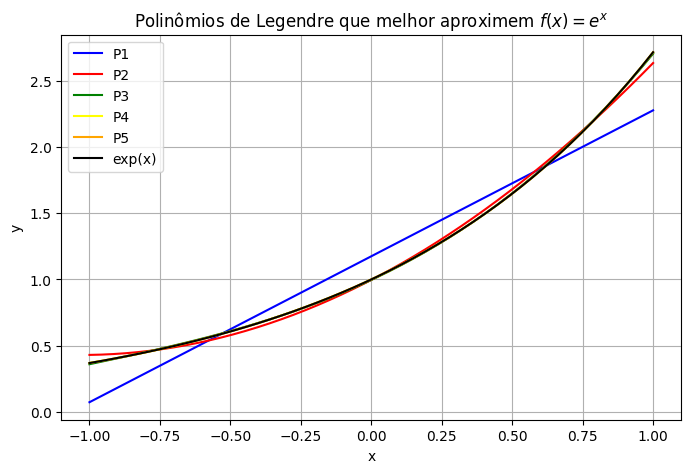


 Erros: 

|| f - P1 ||_2,w =  0.2294624530151091
|| f - P2 ||_2,w =  0.03795488811774879
|| f - P3 ||_2,w =  0.004721109024661315
|| f - P4 ||_2,w =  0.0004704933294933596
|| f - P5 ||_2,w =  3.910870837853507e-05


In [13]:

## Definir os parâmetros e construir os parâmetros de Legendre
n=5
cj=np.zeros((n+1,n+1), dtype=float)
exponen = lambda x: np.exp(x)

## Calcular os coeficientes da solução MMQ
for k in range(1,n+1):
  gs=polinomios_legendre(k)
  for i in range(k+1):
    cj[k][i]=((produto_interno(exponen,gs[i],lambda x: 1, -1, 1))/(produto_interno(gs[i],gs[i],lambda x: 1, -1, 1)))

## Construir funções e plotar

t0=-1
tf=1
P=48
fs = [None]*(n+1)
for i in range(1,n+1):
  gs = polinomios_legendre(i)
  fs[i] = funcao_g(gs, cj[i][:i+1])

cor = ['blue', 'red', 'green', 'yellow', 'orange']

plt.figure(figsize=(8,5))
for i in range(5):
  plt.plot(np.linspace(t0,tf,P), fs[i+1](np.linspace(t0,tf,P)), label='P'+str(i+1), color=cor[i])
plt.plot(np.linspace(t0,tf,P), exponen(np.linspace(t0,tf,P)), label='exp(x)', color='black')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polinômios de Legendre que melhor aproximem $f(x) = e^{x}$')
plt.grid()
plt.legend()
plt.show()

print("\n Erros: \n")
erros = np.zeros(n, dtype=float)
for i in range(1,n+1):
  erros[i-1] = np.sqrt(produto_interno(funcao_f_menos_g(exponen, fs[i]), funcao_f_menos_g(exponen, fs[i]), lambda x: 1, t0, tf))
  print("|| f - P"+str(i)+" ||_2,w = ", erros[i-1])



### Questão 2.4.

Vamos resolver o mesmo problema de aproximação de $f(x) = e^x$, mas agora no intervalo $(c,d) = (0,1)$.

Complete a função *mudanca_intervalo*, que recebe uma função $f$, definida em $(a,b)$, e retorna uma função definida em $(c,d)$. A seguir, repita a questão 2.1, plotando os polinômios de Legendre e verificando os produtos internos $\langle g_k, g_k \rangle$ (quanto eles devem valer agora?).

In [14]:
"""
Retorna uma função definida em um intervalo $c,d$

Entradas:
- f: função definida em (a,b)
- a: limite inferior do intervalo original
- b: limite superior do intervalo original
- c: limite inferior do novo intervalo
- d: limite superior do novo intervalo

Saída:
- ff: função definida em (c,d)
"""
def mudanca_intervalo(f,a,b,c,d):
  ## definir a função
  def ff(t):
    x=a+((b-a)/(d-c))*(t-c) #cambiamos de c a d para a a b porque f va de a a b
    return f(x) #f va de a a b
  return ff





"""
Calcula os polinômios de Legendre de grau n no intervalo (c,d)

Entradas:
- n: grau dos polinômios
- c: limite inferior do intervalo
- d: limite superior do intervalo

Saídas:
- gs: lista com os polinômios de Legendre de graus 0, \dots, n
"""
def polinomios_legendre_mudanca_intervalo(n, c, d):
  gs = [None]*(n+1)
  fs = polinomios_legendre(n)
  for i in range(n+1):
    gs[i]=mudanca_intervalo(fs[i],-1,1,c,d)
  return gs

<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1843/1052957231.py:34: SyntaxWarning: invalid escape sequence '\d'
  - gs: lista com os polinômios de Legendre de graus 0, \dots, n


In [15]:
N=5
gs=polinomios_legendre_mudanca_intervalo(N,0,1)
for k in range(N+1):
  print("<g"+str(k)+",g"+str(k)+"> = ",produto_interno(gs[k],gs[k],lambda x: 1, 0, 1))

<g0,g0> =  1.0
<g1,g1> =  0.3333333333333333
<g2,g2> =  0.20000000000000004
<g3,g3> =  0.1428571428571429
<g4,g4> =  0.11111111111111109
<g5,g5> =  0.09090909090909091


### Questão 2.5.

Utilize os polinômios de Legendre no intervalo $(0,1)$ para encontrar os polinômios $p_n$ de graus $n = 1$ até $n = 5$ que melhor aproximem $f(x) = e^{x}$, no sentido de mínimos quadrados, segundo o produto interno (2) com $\omega (x) \equiv 1$ e $(c,d) = (0,1)$. Plote os polinômios obtidos juntamente com a função $f$, e determine o erro $||f-p_n||_2 := \sqrt{\langle f-p_n, f-p_n\rangle}$ em cada caso.

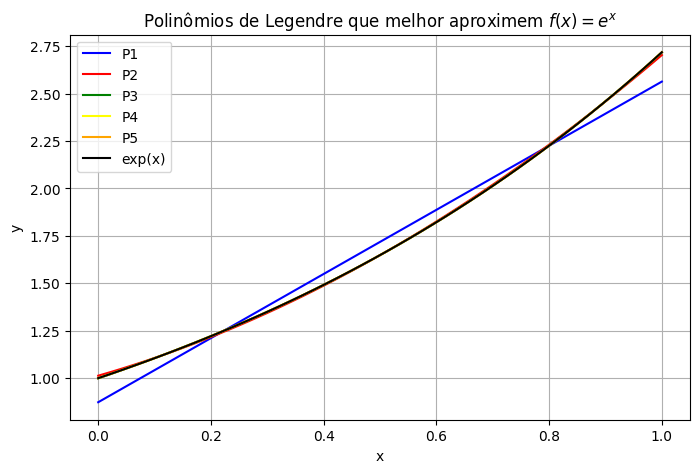


 Erros: 

|| f - P1 ||_2,w =  0.06277119501514142
|| f - P2 ||_2,w =  0.005275930674892345
|| f - P3 ||_2,w =  0.00033127927791790155
|| f - P4 ||_2,w =  1.6611970798742326e-05
|| f - P5 ||_2,w =  6.93531815981134e-07


In [16]:
## Definir os parâmetros e construir os parâmetros de Legendre
n=5
dj=np.zeros((n+1,n+1), dtype=float)

## Calcular os coeficientes da solução MMQ
for k in range(1,n+1):
  gs=polinomios_legendre_mudanca_intervalo(k,0,1)
  for i in range(k+1):
    dj[k][i]=((produto_interno(exponen,gs[i],lambda x: 1, 0, 1))/(produto_interno(gs[i],gs[i],lambda x: 1, 0, 1)))
#print(dj)
## Construir funções e plotar

t0=0
tf=1
P=48
hs = [None]*(n+1)
for i in range(1,n+1):
  gs = polinomios_legendre_mudanca_intervalo(i,0,1)
  hs[i] = funcao_g(gs, dj[i][:i+1])

cor = ['blue', 'red', 'green', 'yellow', 'orange']

plt.figure(figsize=(8,5))
for i in range(5):
  plt.plot(np.linspace(t0,tf,P), hs[i+1](np.linspace(t0,tf,P)), label='P'+str(i+1), color=cor[i])
plt.plot(np.linspace(t0,tf,P), exponen(np.linspace(t0,tf,P)), label='exp(x)', color='black')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polinômios de Legendre que melhor aproximem $f(x) = e^{x}$')
plt.grid()
plt.legend()
plt.show()

print("\n Erros: \n")
errosq = np.zeros(n, dtype=float)
for i in range(1,n+1):
  errosq[i-1] = np.sqrt(produto_interno(funcao_f_menos_g(exponen, hs[i]), funcao_f_menos_g(exponen, hs[i]), lambda x: 1, t0, tf))
  print("|| f - P"+str(i)+" ||_2,w = ", errosq[i-1])

## Parte extra - Introdução a redes neurais

Nesta seção, vamos estudar alguns aspectos básicos de redes neurais, que possuem diversas similaridades com os conceitos vistos no método dos mínimos quadrados. Vamos nos concentrar no caso de funções de $\mathbb{R}$ em $\mathbb{R}$, usando redes neurais com um camada, mas os conceitos se estendem a funções mais gerais e a redes neurais com várias camadas (redes neurais profundas).

O conteúdo apresentado abaixo segue (não apenas) a Seção 1 de https://arxiv.org/pdf/2403.04807

Redes neurais são algoritmos de aprendizado de máquina supervisionado, *i.e.*, que buscam aproximar uma função partindo de pontos conhecidos desta função. Seja $f: \mathbb{R} \to \mathbb{R}$ a função que se deseja aproximar, e $D := \{(x_i,y_i)\}_{i=1,\dots,m}$ o conjunto de dados conhecidos (que serão usados no treinamento da rede neural), com $y_i = f(x_i)$. O objetivo é construir uma função $g(x;\boldsymbol{w})$, que depende de um vetor de parâmetros $\boldsymbol{w} \in W$, e que seja a melhor aproximação para $f$, no sentido de minimizar a **função de perda**

\begin{equation}
  \mathcal{L}(\boldsymbol{w}) := \sum_{i=1}^m l(g(x_i;\boldsymbol{w}),y_i)
\end{equation}

onde $l: \mathbb{R} \times \mathbb{R} \to \mathbb{R}$ é a função de perda avaliada em cada ponto de $D$. Até aqui, a formulação é análoga à do MMQ linear nos parâmetros: neste caso, $g$ é a combinação linear de funções de base, $\boldsymbol{w}$ cont́em os coeficientes dessa combinação linear e $l(x,y) = (x-y)^2$.

Uma rede neural com uma camada é representada esquematicamente da seguinte forma:

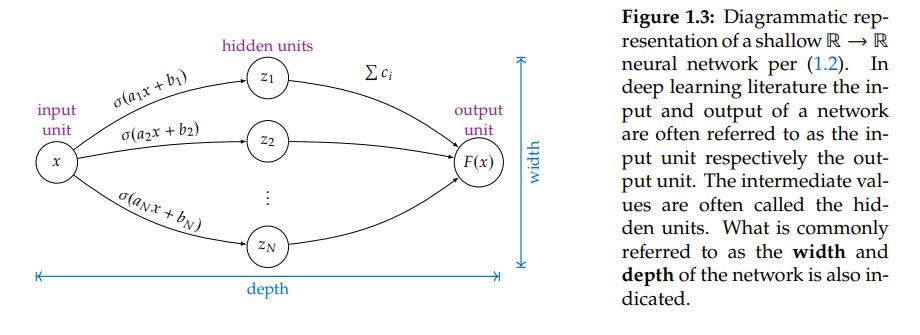


À esquerda e à direita temos respectivamente a entrada e a saída da função $g$. A camada interna (nesse caso, apenas uma), chamada de camada oculta, é formada por $N$ neurônios: cada neurônio $j$ recebe uma entrada na forma $a_jx + b_j$ e retorna um valor $\sigma (a_j x +b_j)$. Os valores retornados por cada neurônio são então combinados linearmente, resultando na função $g$. Ou seja, $g$ é da forma

\begin{equation}
  \tag{3}
  g(x;\boldsymbol{w}) = \sum_{j=1}^N c_j \sigma(a_j x + b_j)
\end{equation}

Para cada neurônio, $a_j$ e $b_j$ são respectivamente o peso linear e o viés. A função $\sigma : \mathbb{R} \to \mathbb{R}$ é chamada de **função de ativação**, pois determina a resposta do neurônio. Existem diferentes tipos de função de ativação usados em redes neurais; o mais comum talvez seja a função **ReLU** (*Rectified Linear Unit*), dada por

\begin{equation}
  \sigma(z) = \max\{0,z\}
\end{equation}

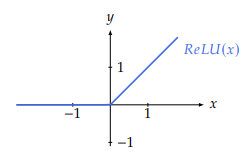

O **treinamento** da rede neural consiste em determinar os parâmetros definindo $g$ (neste caso, o vetor $\boldsymbol{w} = (a_1, b_1, c_1, \dots, a_N, b_N, c_N)^T \in \mathbb{R}^{3N}$). No caso do MMQ linear, o treinamento consiste em resolver o sistema normal. No entanto, a função $g$ acima é não-linear nos parâmetros (nem pode ser linearizada no caso geral), então precisamos recorrer a métodos iterativos para minimização de $\mathcal{L}$; por exemplo, o método do gradiente: dado um chute inicial $\boldsymbol{w}_k$, calculamos

\begin{equation}
  \boldsymbol{w}_{k+1} = \boldsymbol{w}_k - \alpha \nabla \mathcal{L}(\boldsymbol{w}_k)
\end{equation}

Observe que, ao contrário do método do gradiente visto em aula para resolução de sistemas lineares com matriz SPD, em geral não podemos calcular o parãmetro $\alpha$ que minimiza $\mathcal{L}$ ao longo da direção do gradiente; assim, usamos um passo predeterminado (ou mesmo adaptativo, estimado de alguma outra forma). Além disso, o gradiente geralmente é calculado usando técnicas de **diferenciação automática**, que calculam derivadas de forma exata baseando-se na regra de cadeia, o que na prática permitiu a popularização de redes neurais.

Com isso, já temos as ferramentas necessárias para fazer uma implementação simples de uma rede neural com uma camada oculta.

**Observação:** a implementação proposta abaixo é bastante ineficiente em termos de custo computacional, e provavelmente a execução será relativamente demorada, em função dos parâmetros da rede neural e do treinamento. Os resultados obtidos provavelmente não parecerão tão bons (a não ser que você tenha bastante paciência). É possível fazer uma implementação **muito mais eficiente** aproveitando melhor a vetorização em Python (às custas de um código talvez menos intuitivo e legível).

**Formulação do problema**

O objetivo é construir uma rede neural aproximando uma dada função $f(x)$. A rede tem uma camada oculta com $N$ neurônios, na forma (3), onde $\sigma$ é a função ReLU. Os gradientes serão calculados exatamente. A derivada da ReLU não está definida em $z = 0$; em geral, adota-se $\sigma'(0) = 0$. A função erro individual é o erro quadrático $l(x,y) = (x-y)^2$.



### Questão E.1.

Determine o gradiente de $\mathcal{L}$, *i.e.*, determine as derivadas

\begin{equation}
  \frac{\partial \mathcal{L}}{\partial a_p}(\boldsymbol{w}), \qquad \frac{\partial \mathcal{L}}{\partial b_p}(\boldsymbol{w}), \qquad \frac{\partial \mathcal{L}}{\partial c_p}(\boldsymbol{w}), \qquad p = 1, \dots, N
\end{equation}

### Questão E.2.

Complete as funções abaixo:

- *relu*: calcula a função de ativação ReLU
- *relu_der*: calcula a derivada da função de ativação
- *err*: calcula a diferença entre a rede neural e o dado de entrada em um ponto $x$, ou seja, $g(x;\boldsymbol{w}) - y = \sum_{j=1}^N c_j \sigma(a_j x + b_j) - y$ (neste caso, é a raiz da função de perda individual)
- *L*: calcula a função de perda $\mathcal{L}$
- *L_der_ap*, *L_der_bp*, *L_der_cp*: calcula as derivadas determinadas na questão E.1.
- *grad*: calcula $\nabla \mathcal{L}(\mathbf{w})$

In [17]:
"""
Implementa a função de ativação ReLU(z) = max(0,z)

Entrada:
- z: escalar ou vetor de tamanho m

Saída:
- relu_z: função de ativação ReLU calculada em z
"""
def relu(z):
  return np.maximum(0,z)





"""
Implementa a derivada da função de ativação ReLU

Entrada:
- z: escalar ou vetor de tamanho m

Saída:
- relu_der_z: derivada da função de ativação ReLU calculada em z
"""
def relu_der(z):
  c=1.0*(relu(z)>0)
  return c




"""
Calcula a diferença entre a rede neural e o dado de entrada y em um ponto x

Entradas:
- x: ponto x no conjunto D (escalar)
- y: respectivo valor y no conjunto D (escalar)
- a, b, c: parâmetros da rede neural (vetores de tamanho N)

Saida:
- out: erro entre a rede neural e os dado de entrada no ponto x_i
"""
def err(x,y,a,b,c):
  N=len(a)
  suma = 0
  for j in range(N):
    suma += c[j]*relu(a[j]*x+b[j])
  return (suma-y)




"""
Calcula a função de perda (soma dos erros quadráticos), dado um conjunto de parâmetros a,b,c
recorrer
Entradas:
- xs: pontos x no conjunto D (vetor de tamanho m)
- ys: respectivos valores y no conjunto D (vetor de tamanho m)
- a, b, c: parâmetros da rede neural (vetores de tamanho N)

Saída:
- valor: função de perda
"""
def L(xs,ys,a,b,c):
  N = len(xs)
  suma = 0
  for i in range(N):
    suma += (err(xs[i],ys[i],a,b,c))**2
  return suma






"""
Calcula a derivada da função de perda em relação ao parâmetro a_p

Entradas:
- xs: pontos x no conjunto D (vetor de tamanho m)
- ys: respectivos valores y no conjunto D (vetor de tamanho m)
- a, b, c: parâmetros da rede neural (vetores de tamanho N)
- p: índice do parâmetro a_p

Saída:
- valor: derivada da função de perda em relação ao parâmetro a_p (escalar)
"""
def L_der_ap(xs,ys,a,b,c,p):
  m = len(xs)
  suma = 0
  for i in range(m):
    suma+=(err(xs[i], ys[i],a,b,c))*(c[p])*(relu_der(a[p]*xs[i]+b[p]))*(xs[i])
  return (2*suma)





"""
Calcula a derivada da função de perda em relação ao parâmetro b_p

Entradas:
- xs: pontos x no conjunto D (vetor de tamanho m)
- ys: respectivos valores y no conjunto D (vetor de tamanho m)
- a, b, c: parâmetros da rede neural (vetores de tamanho N)
- k: índice do parâmetro b_p

Saída:
- valor: derivada da função de perda em relação ao parâmetro b_p (escalar)
"""
def L_der_bp(xs,ys,a,b,c,p):
  m = len(xs)
  suma = 0
  for i in range(m):
    suma+=(err(xs[i], ys[i],a,b,c))*(c[p])*(relu_der(a[p]*xs[i]+b[p]))
  return (2*suma)



"""
Calcula a derivada da função de perda em relação ao parâmetro c_p

Entradas:
- xs: pontos x no conjunto D (vetor de tamanho m)
- ys: respectivos valores y no conjunto D (vetor de tamanho m)
- a, b, c: parâmetros da rede neural (vetores de tamanho N)
- p: índice do parâmetro c_p

Saída:
- valor: derivada da função de perda em relação ao parâmetro c_p (escalar)
"""
def L_der_cp(xs,ys,a,b,c,p):
  m = len(xs)
  valor = 0
  suma = 0
  for i in range(m):
    suma+=(err(xs[i], ys[i],a,b,c))*(relu(a[p]*xs[i]+b[p]))
  return (2*suma)





"""
Calcula o gradiente da função de perda em relação aos parâmetros a,b,c

Entradas:
- xs: pontos x no conjunto D (vetor de tamanho m)
- ys: respectivos valores y no conjunto D (vetor de tamanho m)
- a, b, c: parâmetros da rede neural (vetores de tamanho N)

Saída:
- gr_a, gr_b, gr_c: gradiente da função de perda em relação aos parâmetros a,b,c (vetores de tamanho n)
"""
def grad(xs,ys,a,b,c):
  gr_a = np.zeros(a.size)
  gr_b = np.zeros(b.size)
  gr_c = np.zeros(c.size)
  for i in range(a.size):
    gr_a[i] = L_der_ap(xs,ys,a,b,c,i)
  for i in range(b.size):
    gr_b[i] = L_der_bp(xs,ys,a,b,c,i)
  for i in range(c.size):
    gr_c[i] = L_der_cp(xs,ys,a,b,c,i)
  return gr_a, gr_b, gr_c

### Questão E.3.

Implemente a função *treinamento*, que realiza o treinamento da rede neural usando o método do gradiente, a partir dos dados no conjunto $D$. Ela retorna os parâmetros estimados e um vetor contendo a função de perda calculada em cada iteração do treinamento.

In [18]:
"""
Realiza o treinamento da rede neural usando o método do gradiente, a partir dos dados no conjunto D.
O treinamento para quando a função de perda for L < eps, ou quando nitermax for atingido

Entradas:
- a0, b0, c0: chute inicial para os parâmetros (vetores de tamanho N)
- eps: tolerância para a convergência (critério sobre a função de perda).
- nitermax: número máximo de iterações
- alpha: passo no método do gradiente (fixo)
- xs: pontos x no conjunto D (vetor de tamanho m)
- ys: respectivos valores y no conjunto D (vetor de tamanho m)

Saída:
- a, b, c: parâmetros da rede neural (vetores de tamanho N)
- Ls: vetor com a função de perda em cada iteração
"""


def treinamento(a0, b0, c0, eps, nitermax, alpha, xs, ys):
  a=a0.copy()
  b=b0.copy()
  c=c0.copy()
  Ls = [L(xs,ys,a,b,c)]
  k = 0
  while (Ls[k] >= eps) and (k < nitermax):
    ga, gb, gc = grad(xs,ys,a,b,c)
    a=a-alpha*ga
    b=b-alpha*gb
    c=c-alpha*gc
    Ls.append(L(xs,ys,a,b,c))
    k+=1
  return a,b,c, Ls

### Questão E.4

Utilize a rede neural para aproximar a função $f(x) = x^2$ no intervalo $[-1,1]$ (ou alguma outra função que você queira). Os pontos de treinamento são selecionados aleatoriamente no intervalo. Plote a evolução da função de perda ao longo das iterações. Plote também o gráfico de $f$ junto com o gráfico da função $g$ obtida. Talvez seja necessário testar alguns parâmetros (número $m$ de pontos, número de neurônios $n$, passo $\alpha$ para o método do gradiente, tolerância $\epsilon$) para obter resultados razoáveis em um tempo de execução razoável. Em particular, talvez seja necessário testar difentes valores fixos de $\alpha$ para garantir a convergência do método iterativo. Se possível, tente alterar as funções implementadas para melhor aproveitas a vetorização em Python.

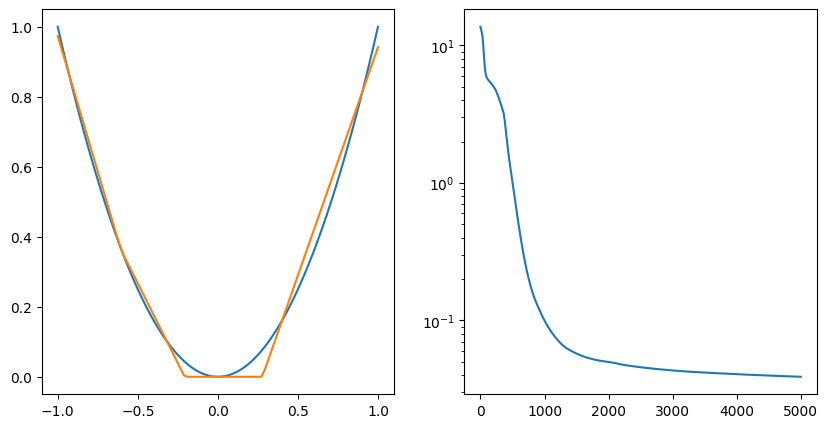

In [20]:
def f_exata(x):
  return x*x

## Número de pontos dados
m = 50

## Intervalo
x0 = -1.
x1 = 1.

## Construção dos pontos dados (aleatoriamente em (-1,1))
x = x0 + (x1-x0)*(np.random.rand(m))
y = f_exata(x)

## Número de neurônios
N = 5

## Parâmetros de iteração
eps = 1e-10
nitermax = 5000
alpha = 0.001

## Chute inicial para os parâmetros (vetores aleatórios)
a0 = np.random.randn(N) * 0.1
b0 = np.random.randn(N) * 0.1
c0 = np.random.randn(N) * 0.1

## Treinamento
a, b, c, Ls = treinamento(a0, b0, c0, eps, nitermax, alpha, x, y)

## A função g obtida
def g(x, a, b, c):
  out = 0.
  for j in range(a.size):
    out += c[j] * relu(a[j] * x + b[j])
  return out

## plotar
fig, ax = plt.subplots(1,2, figsize = (10,5))
x = np.linspace(x0,x1,100)
y = f_exata(x)
ax[0].plot(x,y)

gx = np.zeros(x.size)
for i in range(x.size):
  gx[i] = g(x[i],a,b,c)

ax[0].plot(x,gx)
ax[1].plot(Ls)
ax[1].set_yscale('log')

plt.show()